<a href="https://colab.research.google.com/github/Raka7317/set_project_work/blob/main/FINAL_SET_0.0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


================ STEP 0: SETUP ================
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu

================ STEP 1: DATA LOADING ================

📊 Dataset Sizes
Train: (160000, 2)
Test : (160000, 2)
PHI  : (235795, 2)


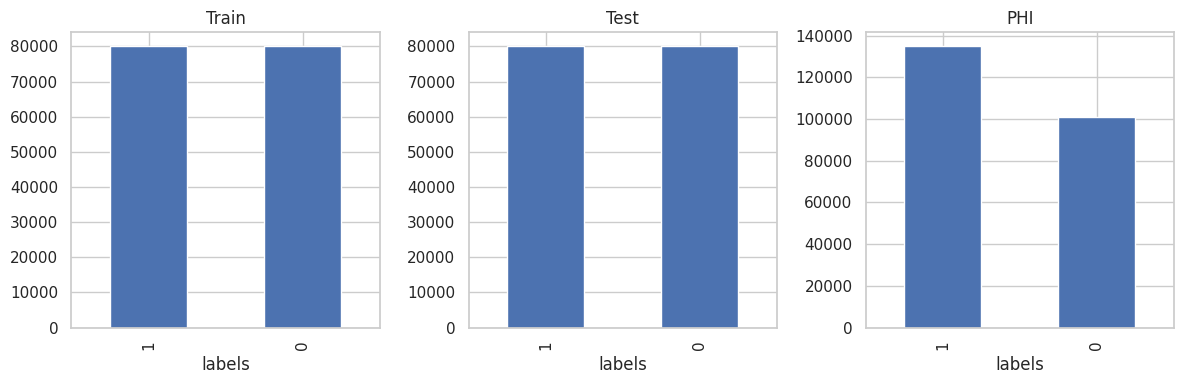


================ STEP 2: LEXICAL FEATURES ================


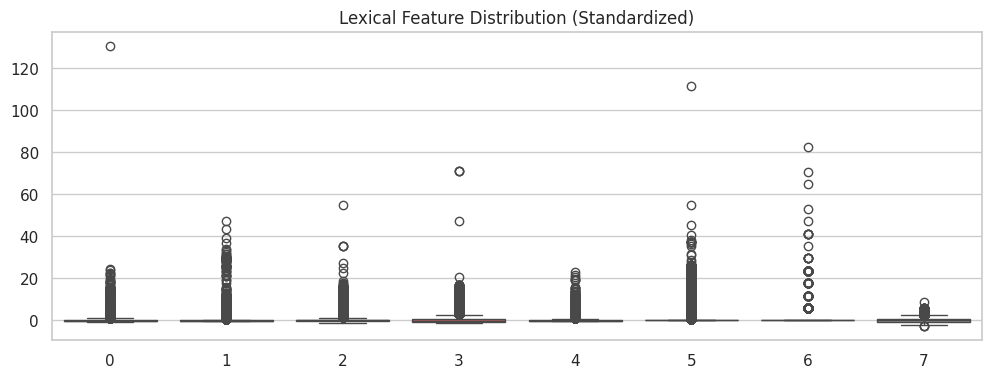


================ STEP 3: TF-IDF FEATURES ================

================ STEP 4: ONLINE ML MODEL ================


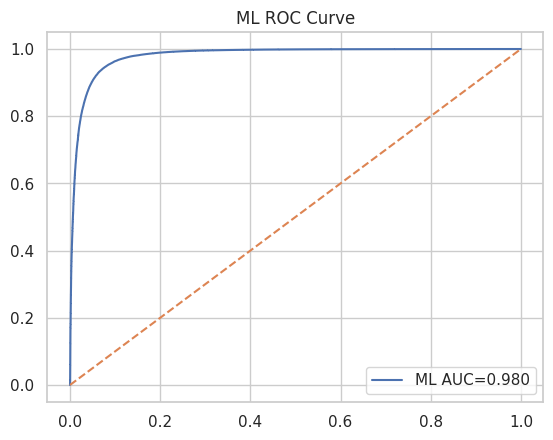


================ STEP 5: ISOLATION FOREST ================


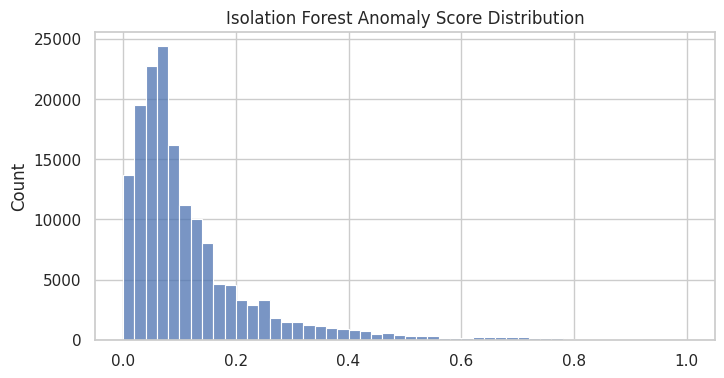


================ STEP 6: DEEP TCN + ATTENTION ================
Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done
Epoch 6 done
Epoch 7 done
Epoch 8 done


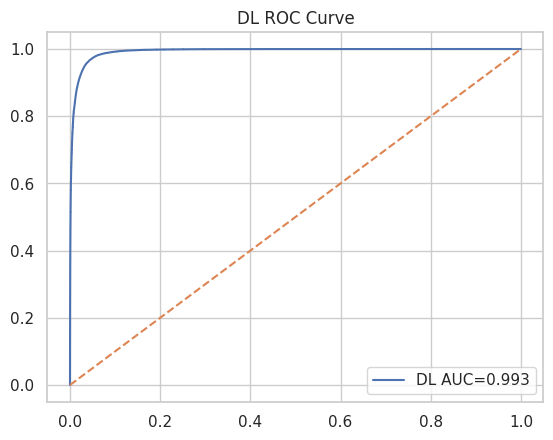


================ STEP 7–9: FUSION + META ================


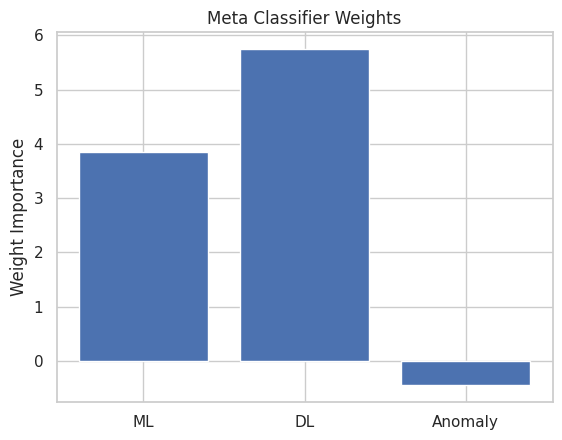

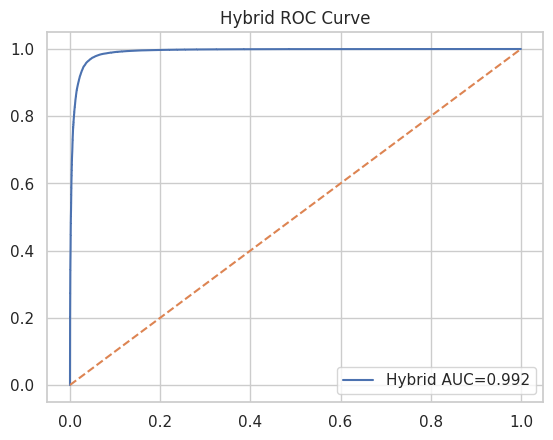

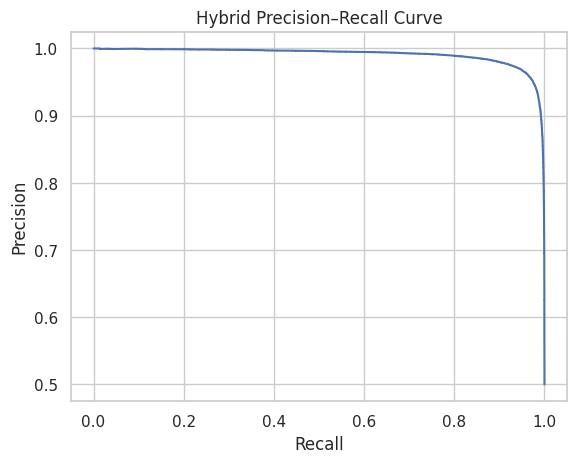

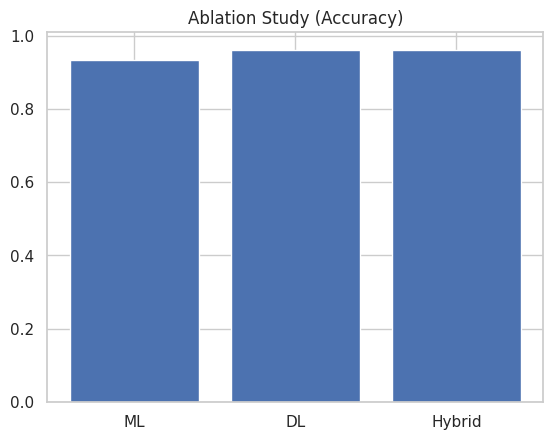


================ STEP 10: DRIFT DETECTION ================


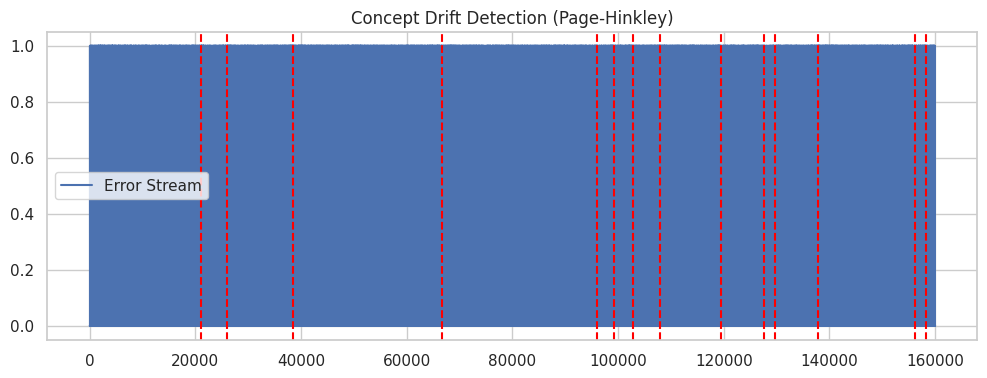


PIPELINE COMPLETED SUCCESSFULLY 🚀


In [4]:
# ==========================================================
# RESEARCH-GRADE HYBRID PHISHING URL DETECTION SYSTEM
# AUTO-TUNED + STACKED + DRIFT-AWARE
# FULL VISUAL + NUMERICAL EXPLANATION (FINAL)
# ==========================================================

print("\n================ STEP 0: SETUP ================")

from google.colab import drive
drive.mount("/content/drive")

import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve, auc
)
from scipy.sparse import hstack

sns.set(style="whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ==========================================================
print("\n================ STEP 1: DATA LOADING ================")

BASE = "/content/drive/MyDrive/data"

def load_data(path):
    df = pd.read_csv(path)
    if "URL" in df.columns:
        df = df.rename(columns={"URL":"url","label":"labels"})
    df = df[["url","labels"]].dropna()
    df["labels"] = df["labels"].astype(int)
    return df

train_df = load_data(os.path.join(BASE,"train.csv"))
test_df  = load_data(os.path.join(BASE,"test.csv"))
phi_df   = load_data(os.path.join(BASE,"phiusiil.csv"))

print("\n📊 Dataset Sizes")
print("Train:", train_df.shape)
print("Test :", test_df.shape)
print("PHI  :", phi_df.shape)

# ---- Class Distribution ----
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); train_df.labels.value_counts().plot(kind="bar",title="Train")
plt.subplot(1,3,2); test_df.labels.value_counts().plot(kind="bar",title="Test")
plt.subplot(1,3,3); phi_df.labels.value_counts().plot(kind="bar",title="PHI")
plt.tight_layout(); plt.show()

# ==========================================================
print("\n================ STEP 2: LEXICAL FEATURES ================")

def lexical_features(url):
    return [
        len(url),
        sum(c.isdigit() for c in url),
        sum(not c.isalnum() for c in url),
        url.count('.'), url.count('-'),
        url.count('%'), url.count('@'),
        math.log2(len(url)+1)
    ]

X_lex_train = np.array([lexical_features(u) for u in train_df.url])
X_lex_test  = np.array([lexical_features(u) for u in test_df.url])
X_lex_phi   = np.array([lexical_features(u) for u in phi_df.url])

scaler_lex = StandardScaler()
X_lex_train = scaler_lex.fit_transform(X_lex_train)
X_lex_test  = scaler_lex.transform(X_lex_test)
X_lex_phi   = scaler_lex.transform(X_lex_phi)

# ---- Lexical Feature Visualization ----
plt.figure(figsize=(12,4))
sns.boxplot(data=pd.DataFrame(X_lex_train))
plt.title("Lexical Feature Distribution (Standardized)")
plt.show()

# ==========================================================
print("\n================ STEP 3: TF-IDF FEATURES ================")

tfidf = TfidfVectorizer(analyzer="char", ngram_range=(2,6), min_df=3, max_features=50000)
X_ng_train = tfidf.fit_transform(train_df.url)
X_ng_test  = tfidf.transform(test_df.url)
X_ng_phi   = tfidf.transform(phi_df.url)

X_train_ml = hstack([X_ng_train, X_lex_train]).tocsr()
X_test_ml  = hstack([X_ng_test, X_lex_test]).tocsr()
X_phi_ml   = hstack([X_ng_phi, X_lex_phi]).tocsr()

# ==========================================================
print("\n================ STEP 4: ONLINE ML MODEL ================")

clf = SGDClassifier(loss="log_loss", class_weight="balanced")
clf.fit(X_train_ml, train_df.labels)

p_ml_test = clf.predict_proba(X_test_ml)[:,1]
p_ml_phi  = clf.predict_proba(X_phi_ml)[:,1]

# ---- ML ROC ----
fpr,tpr,_ = roc_curve(test_df.labels,p_ml_test)
plt.plot(fpr,tpr,label=f"ML AUC={auc(fpr,tpr):.3f}")
plt.plot([0,1],[0,1],'--'); plt.legend(); plt.title("ML ROC Curve"); plt.show()

# ==========================================================
print("\n================ STEP 5: ISOLATION FOREST ================")

iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_lex_train[train_df.labels==0])

a_test = -iso.score_samples(X_lex_test)
a_phi  = -iso.score_samples(X_lex_phi)

scaler_anom = MinMaxScaler()
a_test = scaler_anom.fit_transform(a_test.reshape(-1,1)).flatten()
a_phi  = scaler_anom.transform(a_phi.reshape(-1,1)).flatten()

# ---- Anomaly Score Distribution ----
plt.figure(figsize=(8,4))
sns.histplot(a_test, bins=50)
plt.title("Isolation Forest Anomaly Score Distribution")
plt.show()

# ==========================================================
print("\n================ STEP 6: DEEP TCN + ATTENTION ================")

MAX_LEN = 128
chars = sorted(set("".join(train_df.url.astype(str))))
char2idx = {c:i+1 for i,c in enumerate(chars)}
char2idx["<PAD>"]=0

def encode(u):
    s=[char2idx.get(c,0) for c in str(u)[:MAX_LEN]]
    return s+[0]*(MAX_LEN-len(s))

class URLDS(Dataset):
    def __init__(self, urls, y):
        self.X=[encode(u) for u in urls]
        self.y=y.values
    def __len__(self): return len(self.y)
    def __getitem__(self,i):
        return torch.tensor(self.X[i]), torch.tensor(self.y[i],dtype=torch.float)

train_dl=DataLoader(URLDS(train_df.url,train_df.labels),256,shuffle=True)
test_dl =DataLoader(URLDS(test_df.url,test_df.labels),256)
phi_dl  =DataLoader(URLDS(phi_df.url,phi_df.labels),256)

class DeepTCN(nn.Module):
    def __init__(self,v):
        super().__init__()
        self.emb=nn.Embedding(v,64,padding_idx=0)
        self.conv1=nn.Conv1d(64,128,3,padding=1)
        self.conv2=nn.Conv1d(128,128,3,padding=1)
        self.dropout=nn.Dropout(0.3)
        self.attn=nn.Linear(128,1)
        self.fc=nn.Linear(128,1)
    def forward(self,x):
        x=self.emb(x).transpose(1,2)
        x=torch.relu(self.conv1(x))
        x=torch.relu(self.conv2(x))
        x=self.dropout(x).transpose(1,2)
        w=torch.softmax(self.attn(x).squeeze(-1),1)
        return self.fc((x*w.unsqueeze(-1)).sum(1)).squeeze()

model=DeepTCN(len(char2idx)).to(device)
opt=torch.optim.Adam(model.parameters(),lr=0.001)
lossf=nn.BCEWithLogitsLoss()

for e in range(8):
    for X,y in train_dl:
        X,y=X.to(device),y.to(device)
        opt.zero_grad()
        loss=lossf(model(X),y)
        loss.backward()
        opt.step()
    print(f"Epoch {e+1} done")

def dl_scores(dl):
    model.eval(); s=[]
    with torch.no_grad():
        for X,_ in dl:
            s.extend(torch.sigmoid(model(X.to(device))).cpu().numpy())
    return np.array(s)

p_dl_test = dl_scores(test_dl)

# ---- DL ROC ----
fpr,tpr,_ = roc_curve(test_df.labels,p_dl_test)
plt.plot(fpr,tpr,label=f"DL AUC={auc(fpr,tpr):.3f}")
plt.plot([0,1],[0,1],'--'); plt.legend(); plt.title("DL ROC Curve"); plt.show()

# ==========================================================
print("\n================ STEP 7–9: FUSION + META ================")

meta_X = np.column_stack([p_ml_test,p_dl_test,a_test])
meta_clf = SGDClassifier(loss="log_loss")
meta_clf.fit(meta_X,test_df.labels)

# ---- Meta Weights ----
plt.bar(["ML","DL","Anomaly"],meta_clf.coef_[0])
plt.title("Meta Classifier Weights")
plt.ylabel("Weight Importance")
plt.show()

S_test = meta_clf.predict_proba(meta_X)[:,1]

# ---- Hybrid ROC ----
fpr,tpr,_ = roc_curve(test_df.labels,S_test)
plt.plot(fpr,tpr,label=f"Hybrid AUC={auc(fpr,tpr):.3f}")
plt.plot([0,1],[0,1],'--'); plt.legend(); plt.title("Hybrid ROC Curve"); plt.show()

# ---- Precision Recall ----
prec,rec,_ = precision_recall_curve(test_df.labels,S_test)
plt.plot(rec,prec)
plt.title("Hybrid Precision–Recall Curve")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.show()

# ---- Ablation ----
acc_ml = accuracy_score(test_df.labels,(p_ml_test>0.5))
acc_dl = accuracy_score(test_df.labels,(p_dl_test>0.5))
acc_h  = accuracy_score(test_df.labels,(S_test>0.5))

plt.bar(["ML","DL","Hybrid"],[acc_ml,acc_dl,acc_h])
plt.title("Ablation Study (Accuracy)")
plt.show()

# ==========================================================
print("\n================ STEP 10: DRIFT DETECTION ================")

class PageHinkley:
    def __init__(self,delta=0.002,lam=15):
        self.delta=delta; self.lam=lam; self.reset()
    def reset(self):
        self.mean=0; self.sum=0; self.min=0; self.t=0
    def update(self,x):
        self.t+=1
        self.mean+=(x-self.mean)/self.t
        self.sum+=x-self.mean-self.delta
        self.min=min(self.min,self.sum)
        if self.sum-self.min>self.lam:
            self.reset(); return True
        return False

ph=PageHinkley()
losses=[]; drifts=[]

for i in range(len(test_df)):
    err=int((S_test[i]>0.5)!=test_df.labels.iloc[i])
    losses.append(err)
    if ph.update(err):
        drifts.append(i)

plt.figure(figsize=(12,4))
plt.plot(losses,label="Error Stream")
for d in drifts:
    plt.axvline(d,color="red",ls="--")
plt.legend()
plt.title("Concept Drift Detection (Page-Hinkley)")
plt.show()

print("\nPIPELINE COMPLETED SUCCESSFULLY 🚀")











In [5]:
# ==========================================================
# 🔔 PIPELINE COMPLETION ALERT (CONTINUOUS BEEP)
# ==========================================================

from IPython.display import Audio, display
import numpy as np

def continuous_beep(duration=1.0, freq=800, repeat=5):
    sample_rate = 44100
    t = np.linspace(0, duration, int(sample_rate * duration), False)
    tone = np.sin(freq * t * 2 * np.pi)

    for _ in range(repeat):
        display(Audio(tone, rate=sample_rate, autoplay=True))

print("\n🔔 Pipeline completed! Playing alert sound...")
continuous_beep(duration=0.8, freq=900, repeat=6)



🔔 Pipeline completed! Playing alert sound...
